[*********************100%***********************]  1 of 1 completed


CSV file has been created successfully!
Model Confidence (R2 Score): 0.97


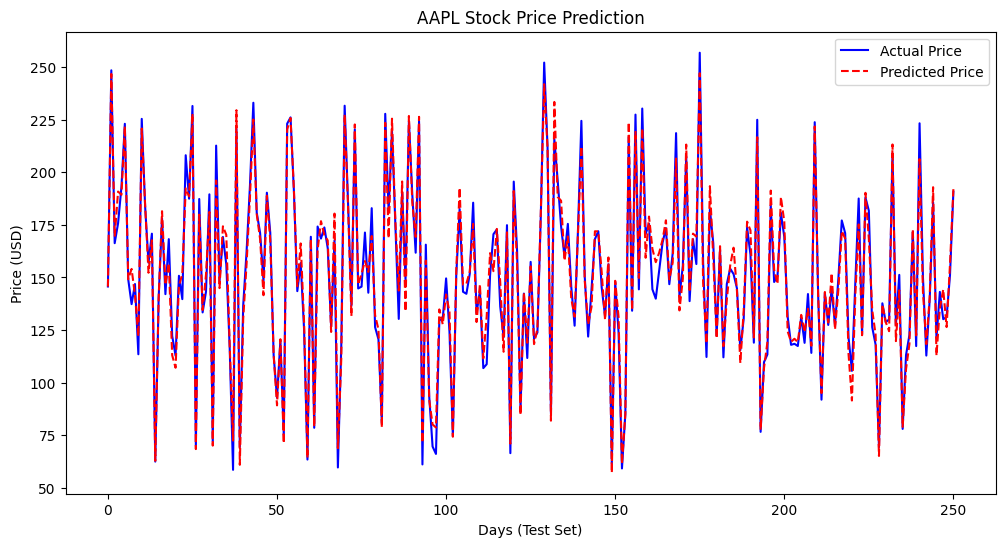

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


ticker = 'AAPL' 
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")

data.to_csv("stock_data.csv")
print("CSV file has been created successfully!")


data['Date'] = data.index
data = data[['Close']]
forecast_out = 7 
data['Prediction'] = data[['Close']].shift(-forecast_out)


X = np.array(data.drop(['Prediction'], axis=1))
X = X[:-forecast_out] 
y = np.array(data['Prediction'])
y = y[:-forecast_out]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


predictions = model.predict(X_test)
print(f"Model Confidence (R2 Score): {model.score(X_test, y_test):.2f}")


plt.figure(figsize=(12,6))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')
plt.title(f'{ticker} Stock Price Prediction')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()